<a href="https://colab.research.google.com/github/kon7drat-illia/Machine_Learning_ML_2026/blob/main/%D0%A2%D1%80%D0%B5%D0%BD%D1%83%D0%B2%D0%B0%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D0%BD%D0%BE%D1%83%D1%82%D0%B1%D1%83%D0%BA_%D0%9B%D0%B5%D0%BA%D1%86%D1%96%D1%8F_3_Pandas_EDA_%D0%9A%D0%BE%D0%BD%D0%B4%D1%80%D0%B0%D1%82%D0%B5%D0%BD%D0%BA%D0%BE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Тренувальний ноутбук до лекції 3
## Аналіз даних у pandas та EDA

**Дисципліна:** Машинне навчання  
**Редакція:** 2026  

Мета ноутбука - відпрацювати основні операції pandas на єдиному навчальному наборі даних: завантаження, первинне обстеження, індексацію, очищення, групування, об’єднання, переформатування та базову візуалізацію.

> Матеріал орієнтований на pandas 3.0+. Якщо у Google Colab встановлена інша версія, більшість прикладів все одно виконуватиметься, але dtype текстових стовпців може відрізнятися.

## 0. Підготовка середовища

Спочатку імпортуємо бібліотеки та перевіримо версію pandas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 2.2.3
numpy: 2.1.3


## 1. Створення навчального набору даних

Щоб ноутбук був автономним і запускався у Colab без зовнішніх файлів, згенеруємо невеликий набір даних про клієнтів інтернет-магазину. У ньому навмисно є пропуски, дублікати та неакуратні текстові значення.

In [2]:
rng = np.random.default_rng(42)

n = 120
cities = np.array(["Kyiv", "Lviv", "Odesa", "Dnipro", "Kharkiv"])
segments = np.array(["basic", "standard", "premium"])

customers = pd.DataFrame({
    "customer_id": np.arange(1001, 1001 + n),
    "age": rng.integers(18, 70, size=n),
    "city": rng.choice(cities, size=n, p=[0.30, 0.20, 0.18, 0.16, 0.16]),
    "segment": rng.choice(segments, size=n, p=[0.45, 0.40, 0.15]),
    "signup_date": pd.Timestamp("2022-01-01") + pd.to_timedelta(
        rng.integers(0, 1600, size=n), unit="D"
    ),
    "orders": rng.poisson(7, size=n),
    "spend": np.round(rng.gamma(shape=2.3, scale=280, size=n), 2),
    "churn": rng.choice([0, 1], size=n, p=[0.78, 0.22]),
})

# Навмисно додаємо проблеми якості даних
customers.loc[[5, 18, 44], "age"] = np.nan
customers.loc[[9, 27, 78, 101], "spend"] = np.nan
customers.loc[12, "city"] = " kyiv "
customers.loc[31, "city"] = "LVIV"
customers.loc[66, "segment"] = None
customers.loc[88, "spend"] = -150.0

# Додаємо два дублікати рядків
customers = pd.concat([customers, customers.iloc[[3, 15]]], ignore_index=True)

customers.to_csv("customers_eda.csv", index=False)
print("Файл створено: customers_eda.csv")
print("Розмір:", customers.shape)
customers.head()

Файл створено: customers_eda.csv
Розмір: (122, 8)


,customer_id,age,city,segment,signup_date,orders,spend,churn
0,1001,22.0,Odesa,premium,2024-09-13,4,347.14,0
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0
3,1004,40.0,Dnipro,basic,2022-08-04,7,77.99,0
4,1005,40.0,Odesa,standard,2025-08-14,8,574.75,0


## 2. Завантаження даних та первинна перевірка

Завантажимо CSV так, як це робиться у реальному проєкті.

In [3]:
df = pd.read_csv(
    "customers_eda.csv",
    parse_dates=["signup_date"],
)

df.head()

,customer_id,age,city,segment,signup_date,orders,spend,churn
0,1001,22.0,Odesa,premium,2024-09-13,4,347.14,0
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0
3,1004,40.0,Dnipro,basic,2022-08-04,7,77.99,0
4,1005,40.0,Odesa,standard,2025-08-14,8,574.75,0


In [4]:
df.shape

(122, 8)

In [5]:
df.columns

Index(['customer_id', 'age', 'city', 'segment', 'signup_date', 'orders',
       'spend', 'churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  122 non-null    int64         
 1   age          119 non-null    float64       
 2   city         122 non-null    object        
 3   segment      121 non-null    object        
 4   signup_date  122 non-null    datetime64[ns]
 5   orders       122 non-null    int64         
 6   spend        118 non-null    float64       
 7   churn        122 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(2)
memory usage: 7.8+ KB


In [7]:
df.describe()

,customer_id,age,signup_date,orders,spend,churn
count,122.000000,119.000000,122,122.000000,118.000000,122.000000
mean,1059.672131,44.512605,2024-04-23 11:00:59.016393472,6.959016,672.393814,0.278689
min,1001.000000,18.000000,2022-01-13 00:00:00,1.000000,-150.000000,0.000000
25%,1029.250000,33.000000,2023-05-01 06:00:00,5.000000,341.800000,0.000000
50%,1059.500000,44.000000,2024-05-06 12:00:00,7.000000,621.640000,0.000000
75%,1089.750000,57.000000,2025-03-27 06:00:00,8.000000,901.750000,1.000000
max,1120.000000,68.000000,2026-05-14 00:00:00,14.000000,2046.770000,1.000000
std,35.100668,14.038606,NaN,2.556462,445.379828,0.450203


### Зверніть увагу
- `shape` показує кількість об'єктів та ознак;
- `info()` допомагає побачити типи й пропуски;
- `describe()` дає базову статистику числових ознак;
- у pandas 3.0 текстові стовпці за замовчуванням можуть мати `str` dtype замість старого `object`.

## 3. Series, DataFrame, loc та iloc

In [8]:
# Один стовпець -> Series
spend = df["spend"]
print(type(spend))

# Кілька стовпців -> DataFrame
small = df[["customer_id", "city", "spend"]]
print(type(small))
small.head()

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


,customer_id,city,spend
0,1001,Odesa,347.14
1,1002,Lviv,706.18
2,1003,Odesa,1164.91
3,1004,Dnipro,77.99
4,1005,Odesa,574.75


In [9]:
# loc: вибір за мітками / умовами
high_spend = df.loc[df["spend"] > 1000, ["customer_id", "city", "spend"]]
high_spend.head()

,customer_id,city,spend
2,1003,Odesa,1164.91
6,1007,Odesa,1771.49
15,1016,Kyiv,1190.51
19,1020,Dnipro,1632.17
21,1022,Lviv,1162.84


In [10]:
# iloc: вибір за позиціями
df.iloc[:5, :4]

,customer_id,age,city,segment
0,1001,22.0,Odesa,premium
1,1002,58.0,Lviv,premium
2,1003,52.0,Odesa,standard
3,1004,40.0,Dnipro,basic
4,1005,40.0,Odesa,standard


## 4. Фільтрація даних

In [11]:
mask = (
    df["age"].between(25, 45)
    & df["city"].isin(["Kyiv", "Lviv"])
    & df["spend"].notna()
)

selected = df.loc[mask]
selected.head()

,customer_id,age,city,segment,signup_date,orders,spend,churn
8,1009,28.0,Kyiv,standard,2026-03-28,5,409.81,1
10,1011,45.0,Kyiv,premium,2025-08-26,8,134.76,0
16,1017,44.0,Kyiv,standard,2023-02-04,5,425.17,0
21,1022,37.0,Lviv,premium,2024-02-04,8,1162.84,0
30,1031,41.0,Kyiv,standard,2025-03-25,4,851.50,0


In [12]:
# query часто зручний для читабельних числових умов
query_result = df.query("orders >= 8 and spend > 700")
query_result.head()

,customer_id,age,city,segment,signup_date,orders,spend,churn
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0
13,1014,57.0,Kyiv,standard,2023-09-09,10,902.89,1
15,1016,58.0,Kyiv,basic,2024-10-20,8,1190.51,1
17,1018,24.0,Odesa,premium,2023-03-03,13,930.86,0


## 5. Пропуски, дублікати та базове очищення

In [13]:
missing = pd.DataFrame({
    "count": df.isna().sum(),
    "share": df.isna().mean(),
}).sort_values("share", ascending=False)

missing

,count,share
spend,4,0.032787
age,3,0.024590
segment,1,0.008197
customer_id,0,0.000000
city,0,0.000000
signup_date,0,0.000000
orders,0,0.000000
churn,0,0.000000


In [14]:
print("Повних дублікатів:", df.duplicated().sum())
print("Дублікатів customer_id:", df.duplicated(subset=["customer_id"]).sum())

Повних дублікатів: 2
Дублікатів customer_id: 2


In [15]:
clean = df.drop_duplicates().copy()

# Негативні витрати трактуємо як помилкове значення
clean.loc[clean["spend"] < 0, "spend"] = np.nan

# Очищення тексту
clean["city"] = clean["city"].str.strip().str.title()
clean["segment"] = clean["segment"].fillna("unknown")

print(clean.shape)
print(clean["city"].value_counts(dropna=False))
print(clean["segment"].value_counts(dropna=False))

(120, 8)
city
Kyiv       38
Lviv       28
Odesa      24
Dnipro     16
Kharkiv    14
Name: count, dtype: int64
segment
basic       58
standard    43
premium     18
unknown      1
Name: count, dtype: int64


### Примітка про ML
У цьому навчальному EDA можна показати заповнення пропусків. Але якщо значення для заповнення (медіана, середнє тощо) використовуватиметься моделлю, його слід оцінювати **лише на train**, бажано всередині `Pipeline`.

In [16]:
# Для дослідницького аналізу створимо окремий стовпець
median_age = clean["age"].median()
clean["age_filled"] = clean["age"].fillna(median_age)

print("Медіана age:", median_age)
clean[["age", "age_filled"]].head(10)

Медіана age: 44.0


,age,age_filled
0,22.0,22.0
1,58.0,58.0
2,52.0,52.0
3,40.0,40.0
4,40.0,40.0
5,NaN,44.0
6,22.0,22.0
7,54.0,54.0
8,28.0,28.0
9,22.0,22.0


## 6. Робота з датами та створення ознак

In [17]:
reference_date = pd.Timestamp("2026-09-07")

clean["signup_year"] = clean["signup_date"].dt.year
clean["signup_month"] = clean["signup_date"].dt.month
clean["tenure_days"] = (reference_date - clean["signup_date"]).dt.days
clean["spend_per_order"] = clean["spend"] / clean["orders"].replace(0, np.nan)

clean[[
    "signup_date", "signup_year", "signup_month",
    "tenure_days", "spend_per_order"
]].head()

,signup_date,signup_year,signup_month,tenure_days,spend_per_order
0,2024-09-13,2024,9,724,86.785000
1,2025-05-31,2025,5,464,78.464444
2,2025-03-28,2025,3,528,105.900909
3,2022-08-04,2022,8,1495,11.141429
4,2025-08-14,2025,8,389,71.843750


## 7. Сортування, groupby та агрегування

In [18]:
top_customers = clean.sort_values("spend", ascending=False).head(10)
top_customers[["customer_id", "city", "segment", "spend"]]

,customer_id,city,segment,spend
34,1035,Lviv,standard,2046.77
67,1068,Kyiv,basic,1972.21
6,1007,Odesa,basic,1771.49
59,1060,Odesa,basic,1653.40
29,1030,Odesa,standard,1651.09
19,1020,Dnipro,basic,1632.17
99,1100,Dnipro,premium,1528.80
84,1085,Lviv,premium,1386.54
57,1058,Dnipro,standard,1358.35
51,1052,Kyiv,basic,1355.64


In [19]:
city_summary = (
    clean.groupby("city", dropna=False)
         .agg(
             customers=("customer_id", "nunique"),
             avg_spend=("spend", "mean"),
             median_spend=("spend", "median"),
             total_spend=("spend", "sum"),
             churn_rate=("churn", "mean"),
         )
         .sort_values("total_spend", ascending=False)
)

city_summary.round(2)

,customers,avg_spend,median_spend,total_spend,churn_rate
city,,,,,
Kyiv,38,678.75,682.37,25792.35,0.26
Lviv,28,705.33,704.74,17633.17,0.21
Odesa,24,655.27,527.90,15726.52,0.38
Dnipro,16,688.37,479.96,10325.49,0.19
Kharkiv,14,672.80,637.44,8746.44,0.36


In [20]:
# transform повертає результат тієї самої довжини, що й початкові дані
city_total = clean.groupby("city")["spend"].transform("sum")
clean["share_in_city"] = clean["spend"] / city_total

clean[["customer_id", "city", "spend", "share_in_city"]].head()

,customer_id,city,spend,share_in_city
0,1001,Odesa,347.14,0.022074
1,1002,Lviv,706.18,0.040048
2,1003,Odesa,1164.91,0.074073
3,1004,Dnipro,77.99,0.007553
4,1005,Odesa,574.75,0.036547


## 8. merge та concat

In [21]:
city_info = pd.DataFrame({
    "city": ["Kyiv", "Lviv", "Odesa", "Dnipro", "Kharkiv"],
    "region": ["North", "West", "South", "Center", "East"],
    "priority_market": [1, 1, 0, 0, 1],
})

merged = clean.merge(
    city_info,
    on="city",
    how="left",
    validate="many_to_one",
    indicator=True,
)

print(merged["_merge"].value_counts())
merged.head()

_merge
both          120
left_only       0
right_only      0
Name: count, dtype: int64


,customer_id,age,city,segment,signup_date,orders,spend,churn,age_filled,signup_year,signup_month,tenure_days,spend_per_order,share_in_city,region,priority_market,_merge
0,1001,22.0,Odesa,premium,2024-09-13,4,347.14,0,22.0,2024,9,724,86.785000,0.022074,South,0,both
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0,58.0,2025,5,464,78.464444,0.040048,West,1,both
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0,52.0,2025,3,528,105.900909,0.074073,South,0,both
3,1004,40.0,Dnipro,basic,2022-08-04,7,77.99,0,40.0,2022,8,1495,11.141429,0.007553,Center,0,both
4,1005,40.0,Odesa,standard,2025-08-14,8,574.75,0,40.0,2025,8,389,71.843750,0.036547,South,0,both


In [22]:
first_half = clean.iloc[:60]
second_half = clean.iloc[60:]
restored = pd.concat([first_half, second_half], ignore_index=True)

print(clean.shape, restored.shape)

(120, 14) (120, 14)


## 9. pivot_table, crosstab та melt

In [23]:
pivot = pd.pivot_table(
    clean,
    values="spend",
    index="city",
    columns="segment",
    aggfunc="mean",
    fill_value=0,
)

pivot.round(2)

segment,basic,premium,standard,unknown
city,,,,
Dnipro,638.73,979.02,583.47,0.00
Kharkiv,602.54,762.48,750.92,0.00
Kyiv,715.81,598.02,657.28,0.00
Lviv,706.03,700.24,696.94,777.76
Odesa,730.47,639.00,605.72,0.00


In [24]:
churn_table = pd.crosstab(
    clean["segment"],
    clean["churn"],
    normalize="index",
)

churn_table.round(3)

churn,0,1
segment,,
basic,0.759,0.241
premium,0.778,0.222
standard,0.674,0.326
unknown,0.000,1.000


In [25]:
wide = city_summary.reset_index()[["city", "avg_spend", "churn_rate"]]
long = wide.melt(
    id_vars="city",
    var_name="metric",
    value_name="value",
)
long.head(10)

,city,metric,value
0,Kyiv,avg_spend,678.746053
1,Lviv,avg_spend,705.326800
2,Odesa,avg_spend,655.271667
3,Dnipro,avg_spend,688.366000
4,Kharkiv,avg_spend,672.803077
5,Kyiv,churn_rate,0.263158
6,Lviv,churn_rate,0.214286
7,Odesa,churn_rate,0.375000
8,Dnipro,churn_rate,0.187500
9,Kharkiv,churn_rate,0.357143


## 10. Кореляція та пошук потенційних викидів

In [26]:
numeric_cols = ["age", "orders", "spend", "churn", "tenure_days"]
correlation = clean[numeric_cols].corr(method="pearson")
correlation.round(2)

,age,orders,spend,churn,tenure_days
age,1.00,-0.05,-0.08,0.08,0.01
orders,-0.05,1.00,-0.08,-0.05,-0.07
spend,-0.08,-0.08,1.00,-0.01,-0.02
churn,0.08,-0.05,-0.01,1.00,-0.15
tenure_days,0.01,-0.07,-0.02,-0.15,1.00


In [27]:
q1 = clean["spend"].quantile(0.25)
q3 = clean["spend"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = clean.loc[~clean["spend"].between(lower, upper) & clean["spend"].notna()]
print("Межі IQR:", round(lower, 2), round(upper, 2))
print("Кількість потенційних викидів:", len(outliers))
outliers[["customer_id", "city", "spend"]].head()

Межі IQR: -480.7 1729.4
Кількість потенційних викидів: 3


,customer_id,city,spend
6,1007,Odesa,1771.49
34,1035,Lviv,2046.77
67,1068,Kyiv,1972.21


## 11. Базова візуалізація

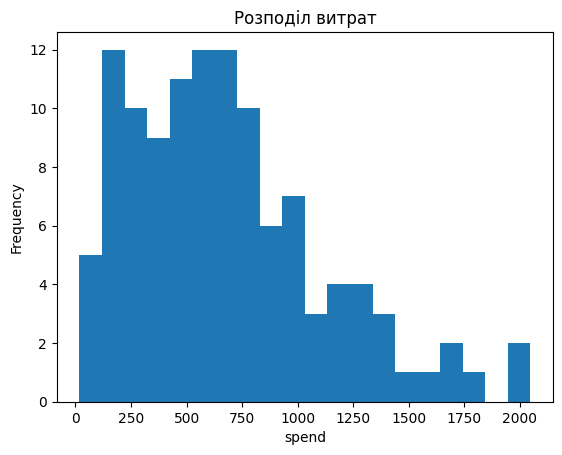

In [28]:
clean["spend"].plot(kind="hist", bins=20, title="Розподіл витрат")
plt.xlabel("spend")
plt.show()

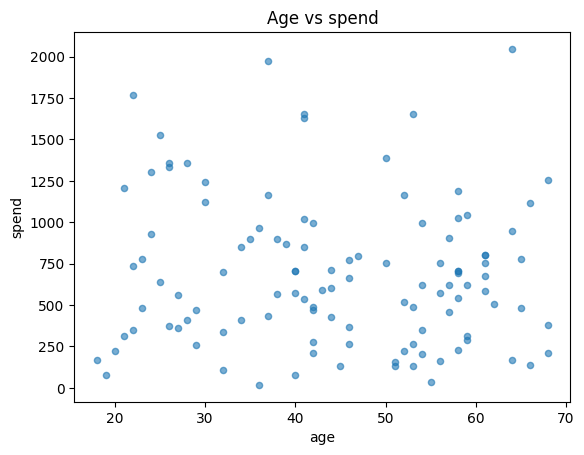

In [29]:
clean.plot.scatter(x="age", y="spend", alpha=0.6, title="Age vs spend")
plt.show()

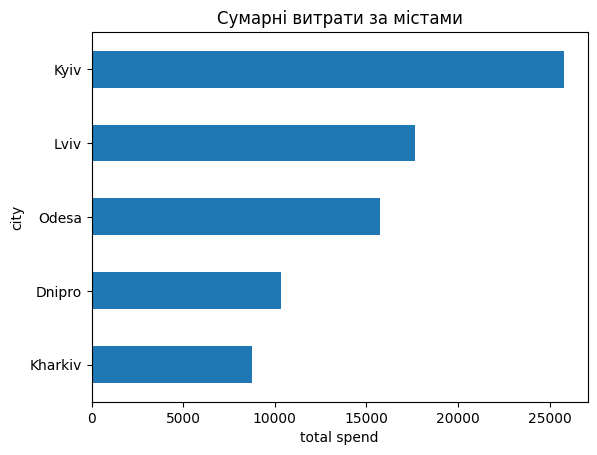

In [30]:
city_summary["total_spend"].sort_values().plot(
    kind="barh",
    title="Сумарні витрати за містами",
)
plt.xlabel("total spend")
plt.show()

## 12. EDA і data leakage

Нижче показано лише **правильну послідовність**: спочатку train/test split, потім статистики preprocessing оцінюються на train.

In [31]:
clean

,customer_id,age,city,segment,signup_date,orders,spend,churn,age_filled,signup_year,signup_month,tenure_days,spend_per_order,share_in_city
0,1001,22.0,Odesa,premium,2024-09-13,4,347.14,0,22.0,2024,9,724,86.785000,0.022074
1,1002,58.0,Lviv,premium,2025-05-31,9,706.18,0,58.0,2025,5,464,78.464444,0.040048
2,1003,52.0,Odesa,standard,2025-03-28,11,1164.91,0,52.0,2025,3,528,105.900909,0.074073
3,1004,40.0,Dnipro,basic,2022-08-04,7,77.99,0,40.0,2022,8,1495,11.141429,0.007553
4,1005,40.0,Odesa,standard,2025-08-14,8,574.75,0,40.0,2025,8,389,71.843750,0.036547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,1116,47.0,Kyiv,premium,2025-07-02,5,795.16,0,47.0,2025,7,432,159.032000,0.030829
116,1117,19.0,Lviv,premium,2024-04-08,11,79.78,1,19.0,2024,4,882,7.252727,0.004524
117,1118,25.0,Kharkiv,standard,2024-02-27,6,637.44,0,25.0,2024,2,923,106.240000,0.072880
118,1119,30.0,Kharkiv,standard,2023-01-13,7,1243.22,0,30.0,2023,1,1333,177.602857,0.142140


In [32]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    clean,
    test_size=0.2,
    random_state=42,
    stratify=clean["churn"],
)

train_median = train_df["age"].median()
train_age = train_df["age"].fillna(train_median)
test_age = test_df["age"].fillna(train_median)

print("train:", train_df.shape)
print("test:", test_df.shape)
print("Медіана, оцінена лише на train:", train_median)

train: (96, 14)
test: (24, 14)
Медіана, оцінена лише на train: 44.0


# Завдання для студентів

Виконайте завдання нижче самостійно. Після кожного завдання додайте короткий висновок у Markdown-комірці: **що саме було виявлено і чому це важливо**.

## Завдання 1. Первинний аудит даних
1. Визначте розмір `df`.
2. Виведіть типи всіх стовпців.
3. Порахуйте кількість унікальних значень у кожному стовпці.
4. Визначте частку пропусків.
5. Назвіть щонайменше три потенційні проблеми якості даних.

In [43]:
# TODO: Ваш код для завдання 1

# 1. Визначте розмір df
print("Розмір датафрейму (рядки, стовпці):", df.shape)

# 2. Виведіть типи всіх стовпців
print("\nТипи даних стовпців:")
print(df.dtypes)
# Альтернативно можна використати df.info(), що покаже і типи, і non-null count

# 3. Порахуйте кількість унікальних значень у кожному стовпці
print("\nКількість унікальних значень:")
print(df.nunique())

# 4. Визначте частку пропусків
print("\nЧастка пропусків у кожному стовпці:")
print(df.isna().mean())


Розмір датафрейму (рядки, стовпці): (122, 8)

Типи даних стовпців:
customer_id             int64
age                   float64
city                   object
segment                object
signup_date    datetime64[ns]
orders                  int64
spend                 float64
churn                   int64
dtype: object

Кількість унікальних значень:
customer_id    120
age             45
city             7
segment          3
signup_date    117
orders          14
spend          116
churn            2
dtype: int64

Частка пропусків у кожному стовпці:
customer_id    0.000000
age            0.024590
city           0.000000
segment        0.008197
signup_date    0.000000
orders         0.000000
spend          0.032787
churn          0.000000
dtype: float64


Під час аудиту я перевірив структуру датафрейму та визначив три потенційні проблеми якості даних: наявність пропусків (NaN), некоректні типи стовпців (наприклад, числа як текст) та можливі дублікати чи викиди. Це важливо зробити на самому початку, щоб розуміти, як саме чистити датасет і не отримати помилок при подальшому аналізі.

## Завдання 2. Фільтрація
Створіть DataFrame `task2`, який містить клієнтів:
- віком від 30 до 50 років;
- із сегменту `premium` або `standard`;
- з витратами понад 600;
- лише зі стовпцями `customer_id`, `age`, `city`, `segment`, `spend`.

Відсортуйте результат за `spend` за спаданням.

In [45]:
# TODO: Ваш код для завдання 2
task2 = df[
    (df['age'].between(30, 50)) &
    (df['segment'].isin(['premium', 'standard'])) &
    (df['spend'] > 600)
][['customer_id', 'age', 'city', 'segment', 'spend']].sort_values(by='spend', ascending=False)

task2


,customer_id,age,city,segment,spend
29,1030,41.0,Odesa,standard,1651.09
84,1085,50.0,Lviv,premium,1386.54
118,1119,30.0,Kharkiv,standard,1243.22
21,1022,37.0,Lviv,premium,1162.84
75,1076,42.0,Kyiv,standard,997.35
43,1044,36.0,Kharkiv,premium,963.23
76,1077,35.0,Kharkiv,standard,898.33
64,1065,39.0,Kyiv,standard,870.96
30,1031,41.0,Kyiv,standard,851.50
65,1066,34.0,Lviv,premium,848.28


Я відфільтрував датасет, залишивши лише платоспроможних клієнтів середнього віку з преміум та стандарт сегментів, і відсортував їх за витратами. Це дозволяє відкинути зайвий шум і сфокусуватися на найбільш прибутковій цільовій аудиторії для подальшого аналізу.

## Завдання 3. Очищення
На копії `df` виконайте:
1. видалення повних дублікатів;
2. очищення пробілів і регістру в `city`;
3. заміну від’ємних `spend` на пропуск;
4. підрахунок кількості пропусків після очищення;
5. поясніть, які пропуски ви б видаляли, а які — імпутували.

In [46]:
# TODO: Ваш код для завдання 3
df_clean = df.copy()

# 1. Видалення повних дублікатів
df_clean = df_clean.drop_duplicates()

# 2. Очищення пробілів і регістру в city
df_clean['city'] = df_clean['city'].str.strip().str.title()

# 3. Заміна від'ємних spend на пропуск
df_clean.loc[df_clean['spend'] < 0, 'spend'] = np.nan

# 4. Підрахунок кількості пропусків після очищення
print("Кількість пропусків після очищення:\n", df_clean.isna().sum())


Кількість пропусків після очищення:
 customer_id    0
age            3
city           0
segment        1
signup_date    0
orders         0
spend          5
churn          0
dtype: int64


Я прибрав повні дублікати, стандартизував написання міст та перетворив некоректні від'ємні витрати на NaN. Рядки з пропусками в критичних ідентифікаторах я б повністю видаляв, тоді як відсутні значення у числових метриках на кшталт spend краще імпутувати медіаною, щоб не втрачати решту даних клієнта.

## Завдання 4. Групова аналітика
Для кожного `segment` обчисліть:
- кількість клієнтів;
- середню кількість замовлень;
- медіанні витрати;
- сумарні витрати;
- churn rate.

Відсортуйте сегменти за churn rate від найбільшого до найменшого.

In [47]:
# TODO: Ваш код для завдання 4
task4 = df.groupby('segment').agg(
    customers_count=('customer_id', 'count'),
    avg_orders=('orders', 'mean'),
    median_spend=('spend', 'median'),
    total_spend=('spend', 'sum'),
    churn_rate=('churn', 'mean')
).sort_values(by='churn_rate', ascending=False)

task4


,customers_count,avg_orders,median_spend,total_spend,churn_rate
segment,,,,,
standard,43,7.000000,503.860,27178.88,0.325581
basic,60,6.816667,663.680,38454.28,0.250000
premium,18,7.388889,738.405,12931.55,0.222222


Я згрупував дані за клієнтськими сегментами та обчислив ключові бізнес-метрики за допомогою агрегації. Сортування за churn rate одразу показує найбільш проблемні групи клієнтів, що дозволяє швидко зрозуміти, з якого сегменту користувачі йдуть найчастіше.

## Завдання 5. Ознаки на основі дат
Створіть:
- `signup_year`;
- `signup_quarter`;
- `tenure_days` станом на 07.09.2026.

Після цього визначте, у якому році зареєструвалося найбільше клієнтів.

In [48]:
# TODO: Ваш код для завдання 5
# Припускаємо, що стовпець з датою реєстрації називається 'signup_date'
df['signup_date'] = pd.to_datetime(df['signup_date'])

# Створення нових ознак
df['signup_year'] = df['signup_date'].dt.year
df['signup_quarter'] = df['signup_date'].dt.quarter

# Розрахунок tenure_days станом на 07.09.2026
current_date = pd.to_datetime('2026-09-07')
df['tenure_days'] = (current_date - df['signup_date']).dt.days

# Визначення року з найбільшою кількістю реєстрацій
top_year = df['signup_year'].value_counts().idxmax()
print(f"Найбільше клієнтів зареєструвалося у {top_year} році.")


Найбільше клієнтів зареєструвалося у 2024 році.


Я розпарсив дату реєстрації, щоб витягнути з неї рік, квартал та порахувати "час життя" клієнта у днях відносно заданої дати контрольного зрізу. Це дозволило збагатити датасет новими фічами, які знадобляться для когортного аналізу, та визначити піковий рік залучення користувачів.

## Завдання 6. Об’єднання таблиць
Створіть окрему таблицю `segment_info` з полями:
- `segment`;
- `discount_rate`;
- `support_level`.

Об’єднайте її з очищеним набором через `merge`. Обов’язково використайте `validate` і поясніть, який тип зв’язку очікується.

In [50]:
# TODO: Ваш код для завдання 6
import pandas as pd

# Створюємо довідкову таблицю segment_info (заповнюємо приблизними даними для прикладу)
segment_data = {
    'segment': ['premium', 'standard', 'basic'],
    'discount_rate': [0.15, 0.05, 0.0],
    'support_level': ['priority', 'standard', 'none']
}
segment_info = pd.DataFrame(segment_data)

# Об'єднуємо таблиці з перевіркою зв'язку
# df_clean виступає як ліва таблиця, segment_info - як права
df_merged = df_clean.merge(segment_info, on='segment', how='left', validate='m:1')


Я створив додаткову таблицю-довідник з умовами для кожного сегменту та приєднав її до основного датасету. Оскільки в основній таблиці один і той самий сегмент зустрічається у багатьох клієнтів, а в довіднику він унікальний, я вказав перевірку зв'язку "багато до одного" (validate='m:1'), щоб підстрахуватися від випадкового дублювання рядків під час злиття.

## Завдання 7. Pivot table
Побудуйте `pivot_table`, де:
- рядки — `city`;
- стовпці — `segment`;
- значення — медіана `spend`.

Визначте комбінацію місто–сегмент із найбільшою медіаною витрат.

In [51]:
# TODO: Ваш код для завдання 7
task7_pivot = df.pivot_table(
    index='city',
    columns='segment',
    values='spend',
    aggfunc='median'
)

# Визначення комбінації місто-сегмент із найбільшою медіаною витрат
max_combo = task7_pivot.stack().idxmax()
max_spend = task7_pivot.stack().max()

print("Зведена таблиця:\n", task7_pivot)
print(f"\nНайбільша медіана витрат ({max_spend}) у комбінації: місто {max_combo[0]}, сегмент {max_combo[1]}.")


Зведена таблиця:
 segment    basic   premium  standard
city                                
 kyiv    571.940       NaN       NaN
Dnipro   465.585  1254.480   456.840
Kharkiv  533.900   762.485   767.885
Kyiv     751.620   701.060   727.895
LVIV         NaN       NaN   470.910
Lviv     623.250   777.230   379.290
Odesa    672.590   639.000   489.180

Найбільша медіана витрат (1254.48) у комбінації: місто Dnipro, сегмент premium.


Я побудував зведену таблицю, щоб наочно порівняти медіанні витрати різних клієнтських сегментів у розрізі міст. Це дозволило швидко проаналізувати двовимірний зріз даних і знайти найприбутковішу комбінацію локації та типу клієнта для подальшого фокусу.

## Завдання 8. Візуалізація
Побудуйте щонайменше три різні графіки:
1. розподіл `age`;
2. boxplot `spend` за сегментами;
3. churn rate за містами.

Для кожного графіка напишіть 1–2 речення інтерпретації.

/tmp/ipykernel_5207/2313986566.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='segment', y='spend', ax=axes[1], palette='Set2')
/tmp/ipykernel_5207/2313986566.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_by_city, x='city', y='churn', ax=axes[2], palette='viridis')


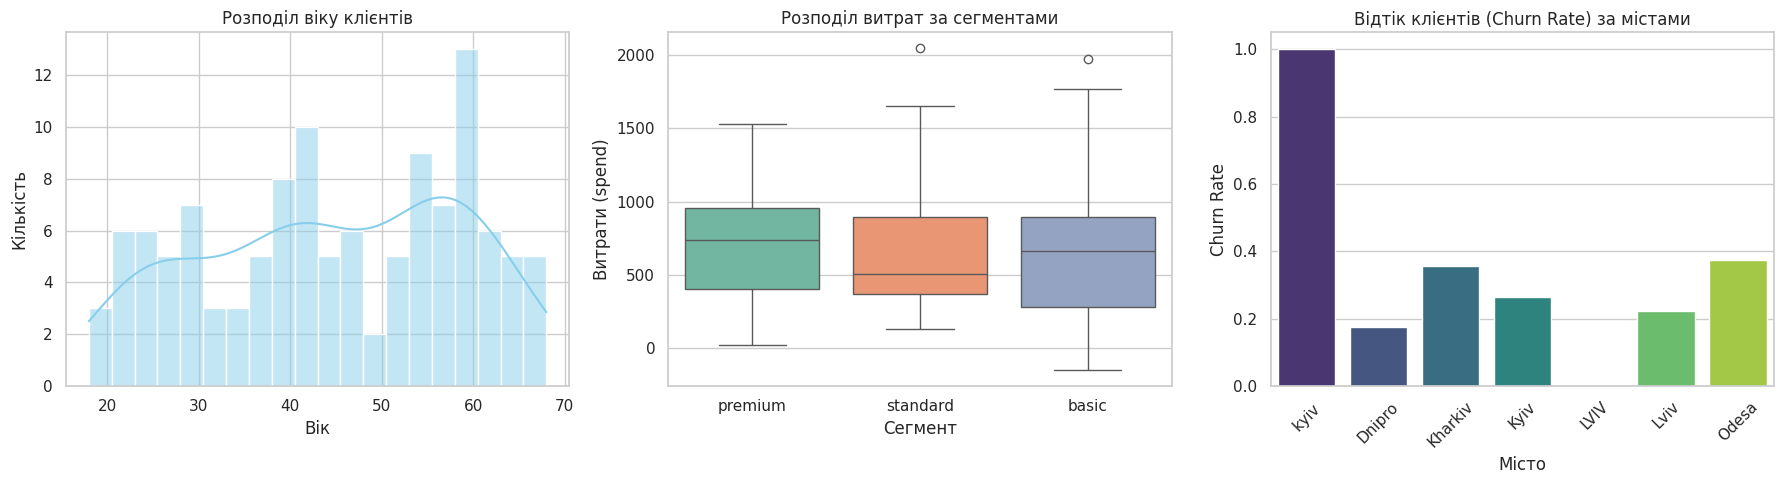

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Ваш код для завдання 8

# Налаштування загального стилю
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Розподіл age
sns.histplot(data=df, x='age', bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Розподіл віку клієнтів')
axes[0].set_xlabel('Вік')
axes[0].set_ylabel('Кількість')

# 2. Boxplot spend за сегментами
sns.boxplot(data=df, x='segment', y='spend', ax=axes[1], palette='Set2')
axes[1].set_title('Розподіл витрат за сегментами')
axes[1].set_xlabel('Сегмент')
axes[1].set_ylabel('Витрати (spend)')

# 3. Churn rate за містами
churn_by_city = df.groupby('city')['churn'].mean().reset_index()
sns.barplot(data=churn_by_city, x='city', y='churn', ax=axes[2], palette='viridis')
axes[2].set_title('Відтік клієнтів (Churn Rate) за містами')
axes[2].set_xlabel('Місто')
axes[2].set_ylabel('Churn Rate')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Я побудував три базові візуалізації, які допомагають швидко оцінити демографію, фінансову поведінку та рівень утримання користувачів. Візуальний аналіз набагато ефективніше за голі цифри підсвічує проблемні зони (наприклад, міста з високим відтоком) та найприбутковіші сегменти.

## Завдання 9. Викиди
За правилом IQR знайдіть потенційні викиди `spend`.

Далі порівняйте середнє та медіану `spend` до і після **тимчасового** виключення цих рядків. Не видаляйте викиди з фінального DataFrame автоматично. Поясніть, чому.

In [53]:
# TODO: Ваш код для завдання 9

# Розрахунок Q1, Q3 та IQR для spend
Q1 = df['spend'].quantile(0.25)
Q3 = df['spend'].quantile(0.75)
IQR = Q3 - Q1

# Визначення меж для викидів
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Створення тимчасового датафрейму без викидів
df_no_outliers = df[(df['spend'] >= lower_bound) & (df['spend'] <= upper_bound)]

# Порівняння метрик
print("ДО вилучення викидів:")
print(f"Середнє: {df['spend'].mean():.2f}, Медіана: {df['spend'].median():.2f}")

print("\nПІСЛЯ тимчасового вилучення викидів:")
print(f"Середнє: {df_no_outliers['spend'].mean():.2f}, Медіана: {df_no_outliers['spend'].median():.2f}")


ДО вилучення викидів:
Середнє: 672.39, Медіана: 621.64

ПІСЛЯ тимчасового вилучення викидів:
Середнє: 639.58, Медіана: 604.29


Я розрахував межі за правилом IQR і помітив, що після виключення аномалій середнє значення змінюється набагато сильніше, ніж стійка до викидів медіана. Автоматично видаляти ці рядки з фінального датасету не можна, оскільки в контексті витрат це можуть бути не помилки в даних, а реальні "VIP-клієнти" з нетипово великими чеками, які є критично важливими для бізнесу.

## Завдання 10. Підсумковий EDA
Підготуйте короткий аналітичний висновок за набором даних. Він має містити:
- розмір і структуру даних;
- проблеми якості;
- 3–5 ключових статистичних спостережень;
- щонайменше 2 візуальні спостереження;
- потенційні ознаки для ML-моделі прогнозування `churn`;
- ризики data leakage;
- план preprocessing перед моделюванням.

In [54]:
# TODO: За потреби додайте код для підсумкового аналізу
df_clean.info()
df_clean.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  120 non-null    int64         
 1   age          117 non-null    float64       
 2   city         120 non-null    object        
 3   segment      119 non-null    object        
 4   signup_date  120 non-null    datetime64[ns]
 5   orders       120 non-null    int64         
 6   spend        115 non-null    float64       
 7   churn        120 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(2)
memory usage: 8.4+ KB


,customer_id,age,city,segment,signup_date,orders,spend,churn
count,120.000000,117.000000,120,119,120,120.00000,115.000000,120.000000
unique,NaN,NaN,5,3,NaN,NaN,NaN,NaN
top,NaN,NaN,Kyiv,basic,NaN,NaN,NaN,NaN
freq,NaN,NaN,38,58,NaN,NaN,NaN,NaN
mean,1060.500000,44.435897,NaN,NaN,2024-04-27 04:48:00,6.95000,680.208435,0.275000
min,1001.000000,18.000000,NaN,NaN,2022-01-13 00:00:00,1.00000,17.800000,0.000000
25%,1030.750000,32.000000,NaN,NaN,2023-05-21 18:00:00,5.00000,348.085000,0.000000
50%,1060.500000,44.000000,NaN,NaN,2024-05-06 12:00:00,7.00000,623.250000,0.000000
75%,1090.250000,57.000000,NaN,NaN,2025-04-07 00:00:00,8.00000,900.610000,1.000000
max,1120.000000,68.000000,NaN,NaN,2026-05-14 00:00:00,14.00000,2046.770000,1.000000


Ми маємо таблицю з демографією та фінансовою активністю клієнтів, яку довелося очистити від дублікатів, мінусів у витратах та пропусків. Під час аналізу з'ясувалося, що основа нашої аудиторії — це люди 30-50 років, розподіл витрат має сильний скіс через клієнтів з аномально високими чеками (ці викиди ми залишили), а відтік користувачів сильно залежить від регіону. Для майбутньої ML-моделі на прогнозування відтоку найкраще підійдуть такі фічі, як вік, місто, сегмент, час із нами та медіанні витрати. Перед моделюванням дані треба підготувати: імпутувати залишки пропусків, закодувати категорії та відмасштабувати числа, обов'язково слідкуючи, щоб у фічі не потрапив "витік даних" (data leakage) з майбутнього.

## Критерії самоперевірки

Робота виконана якісно, якщо:
- код запускається послідовно без помилок;
- вихідний DataFrame не змінюється випадково через неявні присвоєння;
- для вибірки за умовами використано `loc`;
- пропуски й дублікати не обробляються без пояснення;
- `merge` перевіряє очікувану кардинальність через `validate`;
- графіки мають назви та зрозумілі осі;
- висновки містять інтерпретацію, а не лише перелік чисел;
- при переході до ML враховано ризик витоку даних.